# Multi-Depot Vehicle Routing Problem (with clustering)
---
Description:

The Multi-Depot Vehicle Routing Problem (MDVRP) is an extension of the Vehicle Routing Problem where a fleet of vehicles is based at 
multiple depots and must serve a set of customers with known demands. The objective is to assign customers to depots and design routes
for vehicles (respecting capacity, time-window, and route-length constraints) that minimize total cost (e.g., distance or time), while 
ensuring all customer demands are satisfied and each route starts and ends at the same depot.

- Optimization (combinatorial)
- Single-objective
- Constraints (yes)
---

### Import python libraries and set up the project directory

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = os.path.abspath('../../')

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

# Multi Depot Vehicles Routing Problem.
from utils import (load_data, Cluster,
                   initialize_population, cluster_customers_to_depots,
                   evaluate_solution)

### Import the custom GA code

In [2]:
# Import main classes.
from pygenalgo.genome.chromosome import Chromosome
from pygenalgo.utils.utilities import cost_function
from pygenalgo.engines.standard_ga import StandardGA

# Import Selection Operator(s).
from pygenalgo.operators.selection.tournament_selector import TournamentSelector

# Import Crossover Operator(s).
from pygenalgo.operators.crossover.order_crossover import OrderCrossover

# Import Mutation Operator(s).
from pygenalgo.operators.mutation.swap_mutator import SwapMutator

### Read the data and cluster the customers to the depots

In [3]:
# Select a datafile.
# p01_c50_d4_v4
# p02_c50_d4_v2
# p03_c31_d1_v5
filepath = "data/p01_c50_d4_v4.json"

# Load the data from the filepath.
CUSTOMERS, DEPOTS = load_data(filepath)

# Create and store the clusters.
depot_clusters = cluster_customers_to_depots(DEPOTS,
                                             CUSTOMERS,
                                             verbose=True)

Depot-ID: 51 has  13 customers
Depot-ID: 52 has  17 customers
Depot-ID: 53 has  11 customers
Depot-ID: 54 has   9 customers


### Setup the fitness function

In [4]:
# Define the fitness function.
@cost_function(minimize=True)
def func_MDVRP(individual: Chromosome, cluster: Cluster) -> tuple[float, bool]:
    """
    This function computes the total distance
    travelled from all the cars of each depot.
    """
    # Validate the solution.
    total_distance, total_penalty = evaluate_solution(individual, cluster)
    
    # Penalty coefficient.
    p_coeff = 5.0
    
    # Estimate the fitness value.
    f_value = total_distance + (p_coeff * total_penalty)
    
    # Return the total fitness.
    return f_value, False
# _end_def_

In [5]:
# Total distance and penalty values.
total_d, total_p = 0.0, 0

# Store the solutions for plotting.
optimal_solutions = []

# Process all clusters (serially).
for cluster_k in depot_clusters:
    # Extract the depot.
    depot_k = cluster_k.depot
    
    # Extract the customers.
    customers_k = cluster_k.customers
    
    # Create the initial population.
    population_k = initialize_population(customers_k,
                                         depot_k.vehicles,
                                         n_pop=100)
    # Create a StandardGA object.
    test_GA = StandardGA(initial_pop=population_k,
                         fit_func=lambda x: func_MDVRP(x, cluster_k),
                         select_op=TournamentSelector(),
                         crossx_op=OrderCrossover(0.8),
                         mutate_op=SwapMutator(0.2))

    # Optimize the model.
    test_GA(epochs=800, elitism=True, verbose=True)
    
    # Extract the optimal solution from the GA.
    optimal_k = test_GA.best_chromosome()

    # Display an empty line.
    print(" ")
    
    # Extract the validation values.
    dist_k, pnlt_k = evaluate_solution(optimal_k, cluster_k,
                                       verbose=True)
    # Add the output values.
    total_d += dist_k
    total_p += pnlt_k

    # Store the optimal_k solution.
    optimal_solutions.append(optimal_k)

04/26/2026 17:48:47 INFO: Initial Avg. Fitness = -329.3418
04/26/2026 17:48:47 INFO: Epoch:     1 -> Avg. Fitness = -307.9034, Spread = 62.3448
04/26/2026 17:48:51 INFO: Epoch:    81 -> Avg. Fitness = -190.3319, Spread = 28.1849
04/26/2026 17:48:55 INFO: Epoch:   161 -> Avg. Fitness = -192.5224, Spread = 26.0494
04/26/2026 17:48:58 INFO: Epoch:   241 -> Avg. Fitness = -196.0918, Spread = 29.5842
04/26/2026 17:49:02 INFO: Epoch:   321 -> Avg. Fitness = -192.2259, Spread = 27.1606
04/26/2026 17:49:06 INFO: Epoch:   401 -> Avg. Fitness = -192.2625, Spread = 29.8705
04/26/2026 17:49:10 INFO: Epoch:   481 -> Avg. Fitness = -185.4450, Spread = 17.6983
04/26/2026 17:49:13 INFO: Epoch:   561 -> Avg. Fitness = -194.8256, Spread = 26.3848
04/26/2026 17:49:16 INFO: Epoch:   641 -> Avg. Fitness = -195.3414, Spread = 29.4625
04/26/2026 17:49:20 INFO: Epoch:   721 -> Avg. Fitness = -191.6671, Spread = 25.7118
04/26/2026 17:49:24 INFO: Final   Avg. Fitness = -200.9208
04/26/2026 17:49:24 INFO: Initia

Elapsed time: 36.579 seconds.
 
Depot-ID 51: -> Route 0, Distance 51.17, Demand 51
Depot-ID 51: -> Route 1, Distance 51.75, Demand 56
Depot-ID 51: -> Route 2, Distance 48.11, Demand 48
Depot-ID 51: -> Route 3, Distance 26.96, Demand 50


04/26/2026 17:49:30 INFO: Epoch:    81 -> Avg. Fitness = -275.5090, Spread = 44.6345
04/26/2026 17:49:35 INFO: Epoch:   161 -> Avg. Fitness = -268.8227, Spread = 56.4266
04/26/2026 17:49:40 INFO: Epoch:   241 -> Avg. Fitness = -276.7135, Spread = 58.6162
04/26/2026 17:49:46 INFO: Epoch:   321 -> Avg. Fitness = -271.6725, Spread = 62.6710
04/26/2026 17:49:51 INFO: Epoch:   401 -> Avg. Fitness = -263.9568, Spread = 49.9500
04/26/2026 17:49:56 INFO: Epoch:   481 -> Avg. Fitness = -264.0525, Spread = 55.0019
04/26/2026 17:50:01 INFO: Epoch:   561 -> Avg. Fitness = -281.8421, Spread = 86.6889
04/26/2026 17:50:05 INFO: Epoch:   641 -> Avg. Fitness = -267.5463, Spread = 76.3135
04/26/2026 17:50:09 INFO: Epoch:   721 -> Avg. Fitness = -277.4721, Spread = 65.8274
04/26/2026 17:50:13 INFO: Final   Avg. Fitness = -280.3882
04/26/2026 17:50:13 INFO: Initial Avg. Fitness = -191.8414
04/26/2026 17:50:13 INFO: Epoch:     1 -> Avg. Fitness = -184.7919, Spread = 33.2427


Elapsed time: 49.235 seconds.
 
Depot-ID 52: -> Route 0, Distance 80.58, Demand 73
Depot-ID 52: -> Route 1, Distance 42.08, Demand 78
Depot-ID 52: -> Route 2, Distance 39.81, Demand 36
Depot-ID 52: -> Route 3, Distance 72.38, Demand 75


04/26/2026 17:50:17 INFO: Epoch:    81 -> Avg. Fitness = -130.2902, Spread = 15.2697
04/26/2026 17:50:20 INFO: Epoch:   161 -> Avg. Fitness = -127.0406, Spread = 26.0618
04/26/2026 17:50:24 INFO: Epoch:   241 -> Avg. Fitness = -130.6859, Spread = 26.3405
04/26/2026 17:50:28 INFO: Epoch:   321 -> Avg. Fitness = -128.4094, Spread = 26.0492
04/26/2026 17:50:30 INFO: Epoch:   401 -> Avg. Fitness = -123.9622, Spread = 18.7492
04/26/2026 17:50:33 INFO: Epoch:   481 -> Avg. Fitness = -123.6476, Spread = 25.5062
04/26/2026 17:50:36 INFO: Epoch:   561 -> Avg. Fitness = -119.3917, Spread = 8.5760
04/26/2026 17:50:39 INFO: Epoch:   641 -> Avg. Fitness = -124.9541, Spread = 18.5959
04/26/2026 17:50:42 INFO: Epoch:   721 -> Avg. Fitness = -122.4736, Spread = 18.1701
04/26/2026 17:50:46 INFO: Final   Avg. Fitness = -143.0938
04/26/2026 17:50:46 INFO: Initial Avg. Fitness = -190.8661
04/26/2026 17:50:46 INFO: Epoch:     1 -> Avg. Fitness = -180.5180, Spread = 16.6792


Elapsed time: 32.436 seconds.
 
Depot-ID 53: -> Route 1, Distance 55.65, Demand 61
Depot-ID 53: -> Route 2, Distance 35.07, Demand 62
Depot-ID 53: -> Route 3, Distance 25.22, Demand 54


04/26/2026 17:50:49 INFO: Epoch:    81 -> Avg. Fitness = -122.7628, Spread = 22.1767
04/26/2026 17:50:51 INFO: Epoch:   161 -> Avg. Fitness = -127.2266, Spread = 22.6642
04/26/2026 17:50:53 INFO: Epoch:   241 -> Avg. Fitness = -121.3509, Spread = 14.8745
04/26/2026 17:50:56 INFO: Epoch:   321 -> Avg. Fitness = -131.2379, Spread = 26.2798
04/26/2026 17:50:59 INFO: Epoch:   401 -> Avg. Fitness = -126.2385, Spread = 19.0673
04/26/2026 17:51:02 INFO: Epoch:   481 -> Avg. Fitness = -125.0231, Spread = 22.9377
04/26/2026 17:51:05 INFO: Epoch:   561 -> Avg. Fitness = -121.8085, Spread = 18.7536
04/26/2026 17:51:07 INFO: Epoch:   641 -> Avg. Fitness = -127.5724, Spread = 23.0865
04/26/2026 17:51:10 INFO: Epoch:   721 -> Avg. Fitness = -125.8559, Spread = 20.4842
04/26/2026 17:51:12 INFO: Final   Avg. Fitness = -122.1515


Elapsed time: 26.427 seconds.
 
Depot-ID 54: -> Route 1, Distance 44.64, Demand 57
Depot-ID 54: -> Route 3, Distance 69.30, Demand 76


### Display the final solution along with the plot of the vehicles routes

Depot[51] -> [13] -> [25] -> [51] 
Depot[51] -> [41] -> [40] -> [19] -> [42] -> [51] 
Depot[51] -> [17] -> [37] -> [15] -> [45] -> [44] -> [51] 
Depot[51] -> [4] -> [18] -> [51] 
Depot[52] -> [48] -> [23] -> [7] -> [43] -> [24] -> [52] 
Depot[52] -> [46] -> [11] -> [12] -> [47] -> [52] 
Depot[52] -> [14] -> [6] -> [52] 
Depot[52] -> [27] -> [8] -> [26] -> [31] -> [1] -> [32] -> [52] 
Depot[53] -> [30] -> [39] -> [33] -> [10] -> [53] 
Depot[53] -> [34] -> [50] -> [16] -> [9] -> [53] 
Depot[53] -> [49] -> [5] -> [38] -> [53] 
Depot[54] -> [29] -> [20] -> [36] -> [35] -> [54] 
Depot[54] -> [21] -> [2] -> [22] -> [28] -> [3] -> [54] 


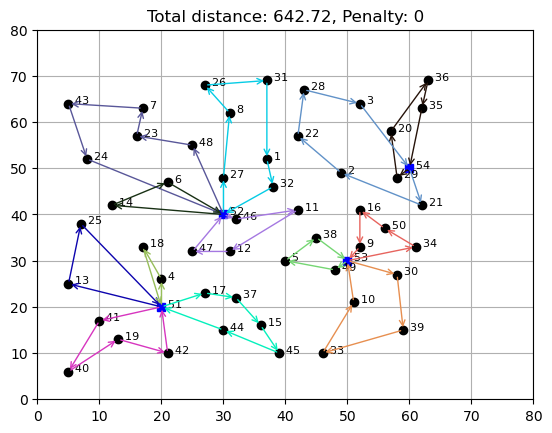

In [6]:
# Fix the rng for the colours.
fixed_rng = np.random.default_rng(756983756837456289375)

# Create a new figure.
fig = plt.figure()
ax = fig.add_subplot(111)

for optimal_k, cluster_k in zip(optimal_solutions,
                                depot_clusters):
    depot_k = cluster_k.depot

    n_vehicles = depot_k.vehicles
    
    customers_k = cluster_k.customers

    n_customers = len(customers_k)

    # Add the customers.
    for c in customers_k:
        ax.plot(c.x, c.y, 'ko')
        ax.annotate(f'  {c.ID}', xy=(c.x, c.y), fontsize=8)
    # _end_for_

    # Add the depot.
    ax.plot(depot_k.x, depot_k.y, 'bs')
    ax.annotate(f'  {depot_k.ID}',
                xy=(depot_k.x, depot_k.y), fontsize=8)

    # Reshape the solution array.
    final_k = np.reshape(optimal_k.values(),
                         (n_customers, n_vehicles))

    # Start computing the total cost.
    for i in range(n_vehicles):
        # Exclude the negative entries.
        customer_ids = final_k[final_k[:, i] >= 0, i]

        # If the array is emtpy
        # continue to the next.
        if customer_ids.size == 0:
            continue

        # Initialize the route using
        # the depot as starting point.
        route = [depot_k]

        # Start printing the route info.
        print(f"Depot[{depot_k.ID}]", end="")

        # Generate the route for this vehicle.
        for c_id in customer_ids.tolist():
            for customer_i in customers_k:
                if customer_i.ID == c_id:
                    route.append(customer_i)
        # _end_for_

        # Get the length of the route.
        n_stops = len(route)

        # Generate a random colour for the route.
        color_i = fixed_rng.random(3)
        
        # Iterate through the route.
        for j, start_point in enumerate(route):
            # Get the coordinates of the first point.
            xj, yj = start_point.x, start_point.y
    
            # The next index ('k') should point
            # at the beginning of the list once
            # we reach at the end.
            k = j + 1 if j < n_stops - 1 else 0
    
            # Get the coordinates of the both points.
            xk, yk = route[k].x, route[k].y
    
            # Put an arrow to show direction.
            ax.annotate("", xy=(xj, yj), xytext=(xk, yk),
                        arrowprops=dict(arrowstyle="<-",
                                        color=color_i))
            # Print the next stop.
            print(f" -> [{route[k].ID}]", end="")
        # _end_for_

        # Print a new line to declutter the screen.
        print(" ")
# _end_for_

ax.grid()
ax.set_xlim([0, 80])
ax.set_ylim([0, 80])

plt.title(f"Total distance: {total_d:.2f}, Penalty: {total_p}")

# Save the figure.
plt.savefig("MDVRP_cluster.pdf", format="pdf", dpi=300)

### End-Of-File